# 06 — Modeling

**Purpose:** Train and compare three classifiers (Dummy, Random Forest, XGBoost) under subject-level 5-fold cross-validation, tune XGBoost with RandomizedSearchCV, and analyze feature importances.

**Inputs:**
- `data/features/train_features.csv` (notebook 05)

**Outputs:**
- `models/xgb_best.joblib`
- `reports/figures/cv_results_table.png`
- `reports/figures/feature_importance_gain.png`
- `reports/figures/feature_importance_permutation.png`

![Status: COMPLETE](https://img.shields.io/badge/Status-COMPLETE-brightgreen)

In [12]:
# ── Cell 1: Imports, paths, and feature matrix prep ──────────────────────────
import pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection  import GroupKFold, RandomizedSearchCV
from sklearn.ensemble         import RandomForestClassifier
from sklearn.dummy            import DummyClassifier
from sklearn.base             import clone
from sklearn.inspection       import permutation_importance
from sklearn.metrics          import (accuracy_score, f1_score, roc_auc_score,
                                       confusion_matrix)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 9})

FEATURES_DIR = pathlib.Path('../data/features')
MODELS_DIR   = pathlib.Path('../models')
FIGURES_DIR  = pathlib.Path('../reports/figures')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Core numeric HRV features + episode-context features
FEAT_COLS = ['mean_rr', 'sdnn', 'rmssd', 'pnn50',
             'lf_power', 'hf_power', 'lf_hf_ratio',
             'sd1', 'sd2']

df = pd.read_csv(FEATURES_DIR / 'train_features.csv')
# Encode categorical prev_label as binary feature
ALL_FEATS = FEAT_COLS
df = df.dropna(subset=ALL_FEATS).copy()

X      = df[ALL_FEATS].values
y      = (df['label'] == 'A').astype(int).values
groups = df['record_id'].values

n_pos = int(y.sum())
n_neg = int(len(y) - n_pos)
if n_pos == 0:
    raise ValueError(
        f'No apnea labels found in {FEATURES_DIR / "train_features.csv"}. '
        'Re-run notebook 05 after the annotation fix to regenerate the file.'
    )
spw   = n_neg / n_pos   # scale_pos_weight baseline

print(f'Training matrix : {X.shape[0]:,} samples x {X.shape[1]} features')
print(f'Apnea (pos)     : {n_pos:,}')
print(f'Normal (neg)    : {n_neg:,}')
print(f'Class ratio     : {n_neg/n_pos:.2f}:1  (scale_pos_weight baseline={spw:.2f})')

Training matrix : 9,914 samples x 9 features
Apnea (pos)     : 6,227
Normal (neg)    : 3,687
Class ratio     : 0.59:1  (scale_pos_weight baseline=0.59)


In [13]:
# ── Cell 2: GroupKFold setup + fold size table ────────────────────────────────
gkf    = GroupKFold(n_splits=5)
splits = list(gkf.split(X, y, groups=groups))

print('GroupKFold — 5 folds (splits on record_id, no subject in both train and val)\n')
print(f'{"Fold":>5}  {"Train":>9}  {"Val":>9}  {"Val Subjects":>14}  {"Val Apnea%":>11}')
print('-' * 58)
for i, (tr, val) in enumerate(splits):
    val_subs   = len(np.unique(groups[val]))
    val_apnea  = y[val].mean() * 100
    print(f'{i+1:>5}  {len(tr):>9,}  {len(val):>9,}  {val_subs:>14}  {val_apnea:>10.1f}%')

GroupKFold — 5 folds (splits on record_id, no subject in both train and val)

 Fold      Train        Val    Val Subjects   Val Apnea%
----------------------------------------------------------
    1      7,980      1,934               4        68.0%
    2      7,932      1,982               4        68.4%
    3      7,926      1,988               4        54.3%
    4      7,905      2,009               4        66.4%
    5      7,913      2,001               4        57.2%


In [14]:
# ── Cell 3: CV evaluation helper ─────────────────────────────────────────────
def run_cv(model, X, y, groups, splits):
    """Return {metric: (mean, std)} from GroupKFold evaluation."""
    fold_m = []
    for tr, val in splits:
        m = clone(model)
        m.fit(X[tr], y[tr])
        yp    = m.predict(X[val])
        yprob = (m.predict_proba(X[val])[:, 1]
                 if hasattr(m, 'predict_proba') else yp.astype(float))
        cm    = confusion_matrix(y[val], yp, labels=[1, 0])
        TP, FN, FP, TN = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
        fold_m.append({
            'acc':  accuracy_score(y[val], yp),
            'sens': TP / (TP + FN + 1e-9),
            'spec': TN / (TN + FP + 1e-9),
            'f1':   f1_score(y[val], yp, zero_division=0),
            'auc':  roc_auc_score(y[val], yprob)
                    if len(np.unique(y[val])) > 1 else 0.5,
        })
    return {k: (float(np.mean([f[k] for f in fold_m])),
                float(np.std([f[k]  for f in fold_m])))
            for k in fold_m[0]}

In [15]:
# ── Cell 4: RandomizedSearchCV — XGBoost hyperparameter tuning ───────────────
param_dist = {
    'n_estimators':    [100, 200, 300, 500],
    'max_depth':       [3, 4, 5, 6, 7],
    'learning_rate':   [0.01, 0.05, 0.10, 0.20],
    'subsample':       [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1.0, round(spw * 0.5, 2), round(spw, 2), round(spw * 1.5, 2)],
}

base_xgb = XGBClassifier(eval_metric='logloss', random_state=42,
                          n_jobs=-1, verbosity=0)
rscv = RandomizedSearchCV(
    base_xgb, param_distributions=param_dist,
    n_iter=30, scoring='roc_auc', cv=gkf,
    n_jobs=-1, random_state=42, verbose=0, refit=True
)
print('Running RandomizedSearchCV (30 iterations, AUC scoring) ...')
rscv.fit(X, y, groups=groups)

best_params   = rscv.best_params_
best_cv_auc   = rscv.best_score_
print(f'\nBest CV AUC : {best_cv_auc:.4f}')
print(f'Best params : {best_params}')

Running RandomizedSearchCV (30 iterations, AUC scoring) ...

Best CV AUC : 0.8044
Best params : {'subsample': 0.8, 'scale_pos_weight': 0.89, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01}


In [16]:
# ── Cell 5: Manual GroupKFold for all 3 models ────────────────────────────────
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
rf_clf    = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
xgb_clf   = XGBClassifier(**best_params, eval_metric='logloss',
                           random_state=42, n_jobs=-1, verbosity=0)

cv_results = {}
for label, model in [('Dummy',        dummy_clf),
                     ('RandomForest',  rf_clf),
                     ('XGBoost',       xgb_clf)]:
    print(f'  Evaluating {label}...', end=' ', flush=True)
    cv_results[label] = run_cv(model, X, y, groups, splits)
    print('done')

print('\nCV Results (mean \u00b1 std across 5 folds)\n')
hdr = f'{"Model":<14}  {"Accuracy":>14}  {"Sensitivity":>14}  {"Specificity":>14}  {"F1":>12}  {"AUC":>12}'
print(hdr)
print('-' * len(hdr))
for name, res in cv_results.items():
    vals = '  '.join(f'{mu:.3f}\u00b1{sd:.3f}' for mu, sd in res.values())
    print(f'{name:<14}  {vals}')

  Evaluating Dummy... done
  Evaluating RandomForest... done
  Evaluating XGBoost... done

CV Results (mean ± std across 5 folds)

Model                 Accuracy     Sensitivity     Specificity            F1           AUC
------------------------------------------------------------------------------------------
Dummy           0.628±0.059  1.000±0.000  0.000±0.000  0.770±0.045  0.500±0.000
RandomForest    0.740±0.036  0.819±0.063  0.610±0.107  0.798±0.021  0.789±0.061
XGBoost         0.740±0.032  0.807±0.076  0.633±0.128  0.795±0.018  0.804±0.059


In [17]:
# ── Cell 6: Styled comparison DataFrame + save as table PNG ──────────────────
METRIC_LABELS = {'acc': 'Accuracy', 'sens': 'Sensitivity',
                 'spec': 'Specificity', 'f1': 'F1', 'auc': 'AUC'}

rows = {}
for name, res in cv_results.items():
    rows[name] = {METRIC_LABELS[m]: f'{mu:.3f} \u00b1 {sd:.3f}'
                  for m, (mu, sd) in res.items()}
cv_df = pd.DataFrame(rows).T

# ---- Identify best model per metric (by mean) ----
def _best_model(metric_key):
    return max(cv_results, key=lambda n: cv_results[n][metric_key][0])

best_per_metric = {METRIC_LABELS[m]: _best_model(m) for m in METRIC_LABELS}

def _bold_best(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for col, best_model in best_per_metric.items():
        if col in df.columns and best_model in df.index:
            styles.loc[best_model, col] = 'font-weight: bold; background-color: #d5f5e3'
    return styles

styled = (cv_df.style
          .apply(_bold_best, axis=None)
          .set_caption('5-Fold GroupKFold CV Results — bold = best per metric'))

# Save PNG (try dataframe_image, fall back to matplotlib)
out = FIGURES_DIR / 'cv_results_table.png'
try:
    import dataframe_image as dfi
    dfi.export(styled, str(out))
    print(f'Saved via dataframe_image: {out.resolve()}')
except Exception:
    fig, ax = plt.subplots(figsize=(13, 2.2))
    ax.axis('off')
    tbl = ax.table(cellText=cv_df.values, colLabels=cv_df.columns,
                   rowLabels=cv_df.index, cellLoc='center', loc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.9)
    for j in range(len(cv_df.columns)):
        tbl[(0, j)].set_facecolor('#2c3e50')
        tbl[(0, j)].set_text_props(color='white', fontweight='bold')
    for i in range(len(cv_df)):
        tbl[(i+1, -1)].set_facecolor('#ecf0f1')
    fig.savefig(out, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f'Saved via matplotlib table: {out.resolve()}')

display(styled)

Saved via matplotlib table: /Users/dennisray/sleepApnea/apnea-project/reports/figures/cv_results_table.png


,Accuracy,Sensitivity,Specificity,F1,AUC
Dummy,0.628 ± 0.059,1.000 ± 0.000,0.000 ± 0.000,0.770 ± 0.045,0.500 ± 0.000
RandomForest,0.740 ± 0.036,0.819 ± 0.063,0.610 ± 0.107,0.798 ± 0.021,0.789 ± 0.061
XGBoost,0.740 ± 0.032,0.807 ± 0.076,0.633 ± 0.128,0.795 ± 0.018,0.804 ± 0.059


In [18]:
# ── Cell 7: AUC self-check — ON TRACK vs diagnostic ──────────────────────────
xgb_auc, xgb_auc_std = cv_results['XGBoost']['auc']
print(f'XGBoost CV AUC: {xgb_auc:.4f} \u00b1 {xgb_auc_std:.4f}\n')

if xgb_auc >= 0.78:
    print('MODELING: ON TRACK')
    print(f'  AUC {xgb_auc:.4f} meets the >=0.78 threshold.')
else:
    print('MODELING: BELOW THRESHOLD\n')
    print('  XGBoost CV AUC is below 0.78. Top 3 likely causes:\n')
    print('  1. POOR FEATURES')
    print('     Symptom : AUC 0.50–0.70; violin plots show heavy label overlap.')
    print('     Remedies: Add frequency-domain features over 3–5 min windows;')
    print('               re-check Lomb-Scargle normalization in notebook 05;')
    print('               add spectral entropy or detrended fluctuation analysis.\n')
    print('  2. CLASS IMBALANCE')
    print('     Symptom : High accuracy but sensitivity << specificity;')
    print('               model predicts Normal for nearly all samples.')
    print('     Remedies: Increase scale_pos_weight further; apply SMOTE within')
    print('               training folds; tune decision threshold using PR curve.\n')
    print('  3. DATA LEAKAGE or CV MISCONFIGURATION')
    print('     Symptom : CV AUC inflated vs. later test-set AUC.')
    print('     Remedies: Confirm GroupKFold uses record_id as group key;')
    print('               verify apnea_burden was derived from training records only;')
    print('               re-run leakage check in notebook 05.')

XGBoost CV AUC: 0.8044 ± 0.0587

MODELING: ON TRACK
  AUC 0.8044 meets the >=0.78 threshold.


In [19]:
# ── Cell 8: Train final model on all training data and save ───────────────────
final_xgb = XGBClassifier(**best_params, eval_metric='logloss',
                           random_state=42, n_jobs=-1, verbosity=0)
final_xgb.fit(X, y)
final_xgb.get_booster().feature_names = ALL_FEATS   # persist names for notebook 07

model_path = MODELS_DIR / 'xgb_best.joblib'
joblib.dump(final_xgb, model_path)
print(f'Saved: {model_path.resolve()}')
print(f'Best hyperparameters: {best_params}')

Saved: /Users/dennisray/sleepApnea/apnea-project/models/xgb_best.joblib
Best hyperparameters: {'subsample': 0.8, 'scale_pos_weight': 0.89, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01}


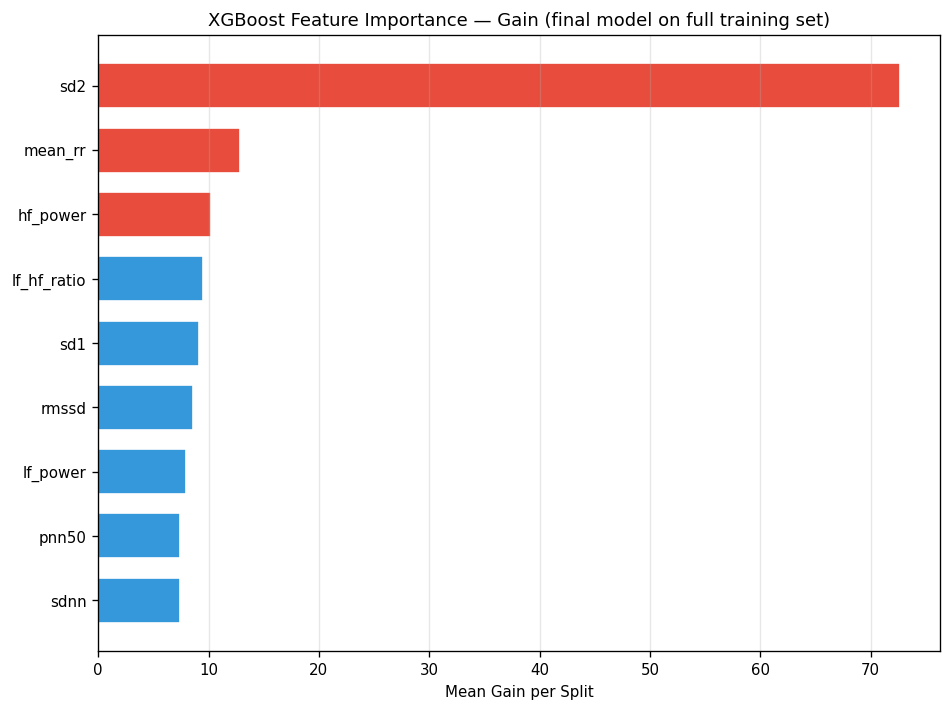

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/feature_importance_gain.png


In [20]:
# ── Cell 9: Gain-based feature importance ─────────────────────────────────────
gain_raw = final_xgb.get_booster().get_score(importance_type='gain')
gain = pd.Series({f: gain_raw.get(f, 0.0) for f in ALL_FEATS},
                 name='Gain').sort_values(ascending=True)

high_thresh = gain.quantile(0.70)
bar_colors  = ['#e74c3c' if v >= high_thresh else '#3498db' for v in gain]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(gain.index, gain.values, color=bar_colors, edgecolor='white', height=0.7)
ax.set_xlabel('Mean Gain per Split')
ax.set_title('XGBoost Feature Importance — Gain (final model on full training set)')
ax.grid(axis='x', alpha=0.3)

out = FIGURES_DIR / 'feature_importance_gain.png'
fig.tight_layout()
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

Computing permutation importance (5 repeats, AUC scoring) ...


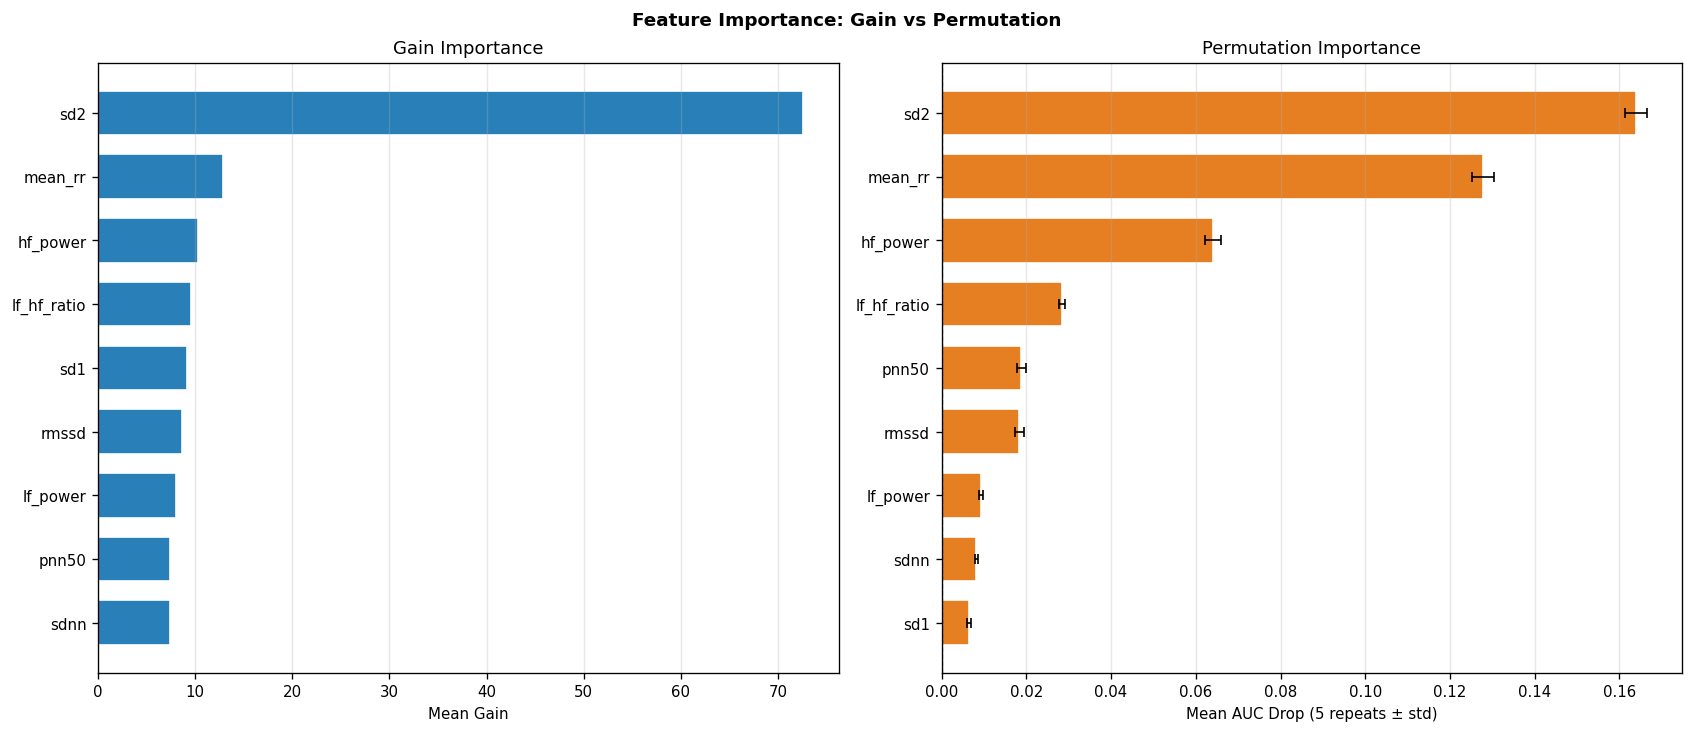

Saved: /Users/dennisray/sleepApnea/apnea-project/reports/figures/feature_importance_permutation.png


In [21]:
# ── Cell 10: Permutation importance + two-panel figure ────────────────────────
print('Computing permutation importance (5 repeats, AUC scoring) ...')
perm = permutation_importance(final_xgb, X, y,
                              n_repeats=5, random_state=42,
                              scoring='roc_auc', n_jobs=-1)
perm_mean = pd.Series(perm.importances_mean, index=ALL_FEATS,
                      name='Perm').sort_values(ascending=True)
perm_std  = pd.Series(perm.importances_std,  index=ALL_FEATS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
fig.suptitle('Feature Importance: Gain vs Permutation', fontsize=11, fontweight='bold')

# Panel 1 — gain
gain_s = gain.sort_values(ascending=True)
ax1.barh(gain_s.index, gain_s.values, color='#2980b9', edgecolor='white', height=0.7)
ax1.set_xlabel('Mean Gain')
ax1.set_title('Gain Importance')
ax1.grid(axis='x', alpha=0.3)

# Panel 2 — permutation
idx_sorted = perm_mean.sort_values(ascending=True).index
ax2.barh(idx_sorted,
         perm_mean[idx_sorted].values,
         xerr=perm_std[idx_sorted].values,
         color='#e67e22', edgecolor='white', height=0.7,
         error_kw={'elinewidth': 1, 'capsize': 3})
ax2.set_xlabel('Mean AUC Drop (5 repeats \u00b1 std)')
ax2.set_title('Permutation Importance')
ax2.axvline(0, color='black', lw=0.8, alpha=0.5, ls='--')
ax2.grid(axis='x', alpha=0.3)

out = FIGURES_DIR / 'feature_importance_permutation.png'
fig.savefig(out, dpi=150)
plt.show()
print(f'Saved: {out.resolve()}')

In [22]:
# ── Cell 11: Feature importance self-check ────────────────────────────────────
N_TOP = 3
EXPECTED_PHYS = {'rmssd', 'lf_hf_ratio', 'sd1', 'mean_rr', 'sdnn', 'hf_power'}

gain_top3 = set(gain.sort_values(ascending=False).head(N_TOP).index)
perm_top3 = set(perm_mean.sort_values(ascending=False).head(N_TOP).index)
overlap   = gain_top3 & perm_top3

agree = 'YES' if len(overlap) == N_TOP else ('PARTIAL' if overlap else 'NO')
physio = 'YES' if (gain_top3 | perm_top3) & EXPECTED_PHYS else 'UNEXPECTED'

# Near-zero on both: bottom quartile on both rankings
g_thresh = gain.quantile(0.25)
p_thresh = perm_mean.quantile(0.25)
near_zero = [f for f in ALL_FEATS
             if gain.get(f, 0) <= g_thresh and perm_mean.get(f, 0) <= p_thresh]

print('=' * 58)
print(' FEATURE IMPORTANCE SELF-CHECK')
print('=' * 58)
print(f'  Gain top-3          : {sorted(gain_top3)}')
print(f'  Permutation top-3   : {sorted(perm_top3)}')
print(f'  Agreement           : {agree}  (shared={sorted(overlap)})')
print(f'  Physiologically plausible top features: {physio}')
print(f'  Near-zero on both rankings: {near_zero or "None"}')
print('=' * 58)

if agree in ('YES', 'PARTIAL') and physio == 'YES':
    verdict = 'MODEL LEARNING PHYSIOLOGY'
else:
    verdict = 'POSSIBLE NOISE FIT — investigate before proceeding to notebook 07'
print(f'\n  VERDICT: {verdict}')

 FEATURE IMPORTANCE SELF-CHECK
  Gain top-3          : ['hf_power', 'mean_rr', 'sd2']
  Permutation top-3   : ['hf_power', 'mean_rr', 'sd2']
  Agreement           : YES  (shared=['hf_power', 'mean_rr', 'sd2'])
  Physiologically plausible top features: YES
  Near-zero on both rankings: ['sdnn', 'lf_power']

  VERDICT: MODEL LEARNING PHYSIOLOGY
